single wide gaussian: L1 = 0.4001 L2 = 0.279
two narrower gaussians: L1 = 0.3503 L2 = 0.2837


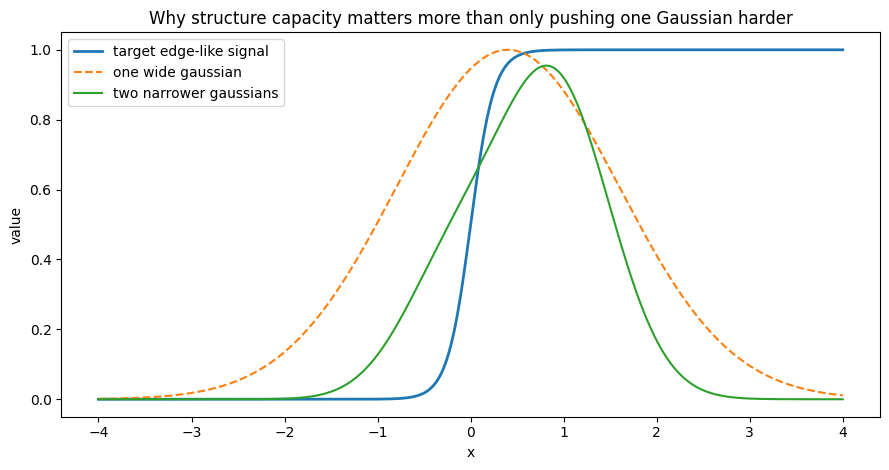

In [1]:
import numpy as np
import matplotlib.pyplot as plt


x = np.linspace(-4, 4, 800)

# 一个带明显边缘的目标信号
# 左边接近 0,右边接近 1,中间有一个过渡区
step_target = 0.5 * (1 + np.tanh(4.0 * x))


def gaussian_1d(x, mu, sigma, amp):
    return amp * np.exp(-0.5 * ((x - mu) / sigma) ** 2)


# 方案 A:一个宽高斯,像"粗糊过去"
pred_one = gaussian_1d(x, mu=0.4, sigma=1.2, amp=1.0)

# 方案 B:两个更窄的高斯,更像"有了更多局部自由度"
pred_two = (
    gaussian_1d(x, mu=-0.2, sigma=0.55, amp=0.35)
    + gaussian_1d(x, mu=0.9, sigma=0.60, amp=0.90)
)


def l1(a, b):
    return np.mean(np.abs(a - b))


def l2(a, b):
    return np.mean((a - b) ** 2)


print('single wide gaussian: L1 =', round(l1(pred_one, step_target), 4),
      'L2 =', round(l2(pred_one, step_target), 4))
print('two narrower gaussians: L1 =', round(l1(pred_two, step_target), 4),
      'L2 =', round(l2(pred_two, step_target), 4))

plt.figure(figsize=(9, 4.8))
plt.plot(x, step_target, label='target edge-like signal', linewidth=2)
plt.plot(x, pred_one, '--', label='one wide gaussian')
plt.plot(x, pred_two, label='two narrower gaussians')
plt.legend()
plt.xlabel('x')
plt.ylabel('value')
plt.title('Why structure capacity matters more than only pushing one Gaussian harder')
plt.tight_layout()
plt.show()